In [ ]:

import os

# Set Kaggle credentials directly
os.environ['KAGGLE_USERNAME'] = 'harrisimran'
os.environ['KAGGLE_KEY'] = 'KGAT_f1110eaebd5ba1fdd0f3323118285636'

!pip install kaggle -q

# Download the dataset (no unzip)
!kaggle datasets download -d harrisimran/mamia-dataset -p /content/

print("✅ Download complete!")

Dataset URL: https://www.kaggle.com/datasets/harrisimran/mamia-dataset
License(s): apache-2.0
100% 13.8G/13.8G [03:14<00:00, 76.4MB/s]

✅ Download complete!


In [ ]:
# Cell 3: Unzip
import zipfile
import os

print("Unzipping... this may take a few minutes")

with zipfile.ZipFile("/content/mamia-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/mamia_dataset")

print("✅ Unzip complete!")
print("\nFiles extracted:")
print(os.listdir("/content/mamia_dataset"))

Unzipping... this may take a few minutes
✅ Unzip complete!

Files extracted:
['mama_mia_v2']


In [ ]:
import os

# Delete the zip file (no longer needed)
zip_path = "/content/mamia-dataset.zip"
if os.path.exists(zip_path):
    os.remove(zip_path)
    print("✅ Zip deleted — space freed!")

# Check new space
import shutil
total, used, free = shutil.disk_usage("/content")
print(f"Free space: {free/1024/1024/1024:.2f} GB")

✅ Zip deleted — space freed!
Free space: 20.83 GB


In [ ]:
# Cell 1 FINAL FIXED PATHS
import os
import pandas as pd
import numpy as np

# ✅ CORRECT BASE PATH
base_path   = "/content/mamia_dataset/mama_mia_v2"
images_path = f"{base_path}/images"
seg_path    = f"{base_path}/segmentations"
expert_path = f"{seg_path}/expert"
auto_path   = f"{seg_path}/automatic"
excel_path  = f"{base_path}/clinical_and_imaging_info.xlsx"
splits_path = f"{base_path}/train_test_splits.xlsx"

# Verify all paths
print("Checking paths...\n")
paths = {
    "Base":    base_path,
    "Images":  images_path,
    "Expert":  expert_path,
    "Auto":    auto_path,
    "Excel":   excel_path,
    "Splits":  splits_path
}
for name, path in paths.items():
    exists = "✅" if os.path.exists(path) else "❌"
    print(f"  {exists} {name}: {path}")

# Count patients
all_patients    = sorted(os.listdir(images_path))
expert_patients = sorted(os.listdir(expert_path))
auto_patients   = sorted(os.listdir(auto_path))

# Breakdown
duke  = [p for p in all_patients if 'DUKE'  in p]
ispy2 = [p for p in all_patients if 'ISPY2' in p]
ispy1 = [p for p in all_patients if 'ISPY1' in p]
nact  = [p for p in all_patients if 'NACT'  in p]

print(f"\n=== DATASET SUMMARY ===")
print(f"Total patients:  {len(all_patients)}")
print(f"  DUKE:          {len(duke)}")
print(f"  ISPY2:         {len(ispy2)}")
print(f"  ISPY1:         {len(ispy1)}")
print(f"  NACT:          {len(nact)}")
print(f"\nExpert masks:    {len(expert_patients)}")
print(f"Auto masks:      {len(auto_patients)}")

# Valid = has image AND expert mask
valid_patients = [
    p for p in all_patients
    if p in expert_patients
]
print(f"\n✅ Valid patients: {len(valid_patients)}")
print(f"\nFirst 5: {valid_patients[:5]}")
print(f"Last  5: {valid_patients[-5:]}")

Checking paths...

  ✅ Base: /content/mamia_dataset/mama_mia_v2
  ✅ Images: /content/mamia_dataset/mama_mia_v2/images
  ✅ Expert: /content/mamia_dataset/mama_mia_v2/segmentations/expert
  ✅ Auto: /content/mamia_dataset/mama_mia_v2/segmentations/automatic
  ✅ Excel: /content/mamia_dataset/mama_mia_v2/clinical_and_imaging_info.xlsx
  ✅ Splits: /content/mamia_dataset/mama_mia_v2/train_test_splits.xlsx

=== DATASET SUMMARY ===
Total patients:  225
  DUKE:          44
  ISPY2:         146
  ISPY1:         29
  NACT:          6

Expert masks:    225
Auto masks:      225

✅ Valid patients: 0

First 5: []
Last  5: []


In [ ]:
# Cell 2: Load Excel
df = pd.read_excel(excel_path)

print("✅ Clinical data loaded!")
print(f"Shape: {df.shape}")
print(f"\nAll columns:")
for i, col in enumerate(df.columns):
    sample = df[col].dropna().iloc[0] \
             if len(df[col].dropna()) > 0 else 'N/A'
    print(f"  [{i}] {col} → example: {sample}")

✅ Clinical data loaded!
Shape: (225, 50)

All columns:
  [0] patient_id → example: DUKE_041
  [1] dataset → example: DUKE
  [2] bilateral_breast_cancer → example: 0
  [3] multifocal_cancer → example: 0.0
  [4] nac_agent → example: Paclitaxel + MK-2206
  [5] endocrine_therapy → example: 0.0
  [6] anti_her2_neu_therapy → example: 0.0
  [7] pcr → example: 0.0
  [8] mastectomy_post_nac → example: 1.0
  [9] days_to_follow_up → example: 2567.0
  [10] days_to_recurrence → example: 0.0
  [11] days_to_metastasis → example: 0.0
  [12] days_to_death → example: 0.0
  [13] hr → example: 1.0
  [14] er → example: 1.0
  [15] pr → example: 1.0
  [16] her2 → example: 0.0
  [17] mammaprint → example: 0.0
  [18] oncotype_score → example: 27.0
  [19] nottingham_grade → example: intermediate
  [20] tumor_subtype → example: luminal
  [21] age → example: 67
  [22] menopause → example: post
  [23] ethnicity → example: caucasian
  [24] has_implant → example: 0
  [25] weight → example: 68.039
  [26] patient_size

In [ ]:
# Cell 3: Build real labels from clinical data
print("Building real labels...\n")

# Convert to set for O(1) lookup; also accept ALL df patients if valid_patients is empty
_valid_set = set(valid_patients) if valid_patients else set(df['patient_id'].astype(str).str.strip())
if not valid_patients:
    print("⚠️  valid_patients was empty — using all patients from df\n")

# Subtype mapping from 'tumor_subtype' column
subtype_map = {
    # space / hyphen variants
    'luminal':         0,
    'luminal a':       0,
    'luminal b':       0,
    'her2':            1,
    'her2+':           1,
    'her2-enriched':   1,
    'tnbc':            2,
    'triple negative': 2,
    'triple-negative': 2,
    # underscore variants (actual values in data)
    'luminal_a':       0,
    'luminal_b':       0,
    'her2_enriched':   1,
    'her2_pure':       1,
    'triple_negative': 2,
}

# Grade mapping from 'nottingham_grade' column
grade_map = {
    'low':          0,
    'intermediate': 1,
    'high':         2,
    '1': 0, '2': 1, '3': 2,
     1:  0,  2:  1,  3:  2,
}

subtype_names = ['Luminal', 'HER2-enriched', 'TNBC']
grade_names   = ['Low', 'Intermediate', 'High']

real_labels = {}
unmapped    = {'subtype': set(), 'grade': set()}

def _get(row, col, default):
    """pandas-safe get: handles missing columns and NaN values."""
    val = row[col] if col in row.index else default
    return default if (val != val) else val  # NaN != NaN

for _, row in df.iterrows():
    pid = str(_get(row, 'patient_id', '')).strip()
    if not pid or pid not in _valid_set:
        continue

    # ── Subtype ───────────────────────────────────────────────────────────
    raw_sub = str(_get(row, 'tumor_subtype', '')).lower().strip()
    if raw_sub not in subtype_map and raw_sub not in ('', 'nan', 'none'):
        unmapped['subtype'].add(raw_sub)
    sub_idx = subtype_map.get(raw_sub, 0)

    # ── Grade ─────────────────────────────────────────────────────────────
    raw_grd_val = _get(row, 'nottingham_grade', 'intermediate')
    raw_grd_str = str(raw_grd_val).lower().strip()
    grd_idx = grade_map.get(raw_grd_val,
              grade_map.get(raw_grd_str, 1))
    if raw_grd_str not in grade_map and raw_grd_val not in grade_map:
        unmapped['grade'].add(raw_grd_str)

    real_labels[pid] = {
        'subtype':     sub_idx,
        'grade':       grd_idx,
        'raw_subtype': raw_sub,
        'raw_grade':   raw_grd_str,
        'age':         _get(row, 'age',       55),
        'menopause':   _get(row, 'menopause', 'unknown'),
        'ethnicity':   _get(row, 'ethnicity', 'unknown'),
        'er':          _get(row, 'er',         0),
        'pr':          _get(row, 'pr',         0),
        'her2':        _get(row, 'her2',       0),
        'pcr':         _get(row, 'pcr',        0),
        'hr':          _get(row, 'hr',         0),
        'weight':      _get(row, 'weight',     0),
        'dataset':     _get(row, 'dataset',   'DUKE'),
    }

# ── Unmapped value warnings ───────────────────────────────────────────────────
for field, values in unmapped.items():
    clean = {v for v in values if v not in ('', 'nan', 'none')}
    if clean:
        print(f"⚠️  Unmapped {field} values (defaulted): {clean}")

print(f"✅ Labels built: {len(real_labels)} patients")

# ── Distributions ─────────────────────────────────────────────────────────────
subtypes = [v['subtype'] for v in real_labels.values()]
grades   = [v['grade']   for v in real_labels.values()]

if subtypes:
    print("\nSubtype distribution:")
    for i, name in enumerate(subtype_names):
        count = subtypes.count(i)
        print(f"  {name}: {count} ({count/len(subtypes)*100:.1f}%)")

    print("\nGrade distribution:")
    for i, name in enumerate(grade_names):
        count = grades.count(i)
        print(f"  {name}: {count} ({count/len(grades)*100:.1f}%)")
else:
    print("❌ No labels built — check df contents and valid_patients")

Building real labels...

⚠️  valid_patients was empty — using all patients from df

✅ Labels built: 225 patients

Subtype distribution:
  Luminal: 114 (50.7%)
  HER2-enriched: 35 (15.6%)
  TNBC: 76 (33.8%)

Grade distribution:
  Low: 1 (0.4%)
  Intermediate: 209 (92.9%)
  High: 15 (6.7%)


Patient:   DUKE_041
MRI shape: (512, 512, 168)
Slices:    168


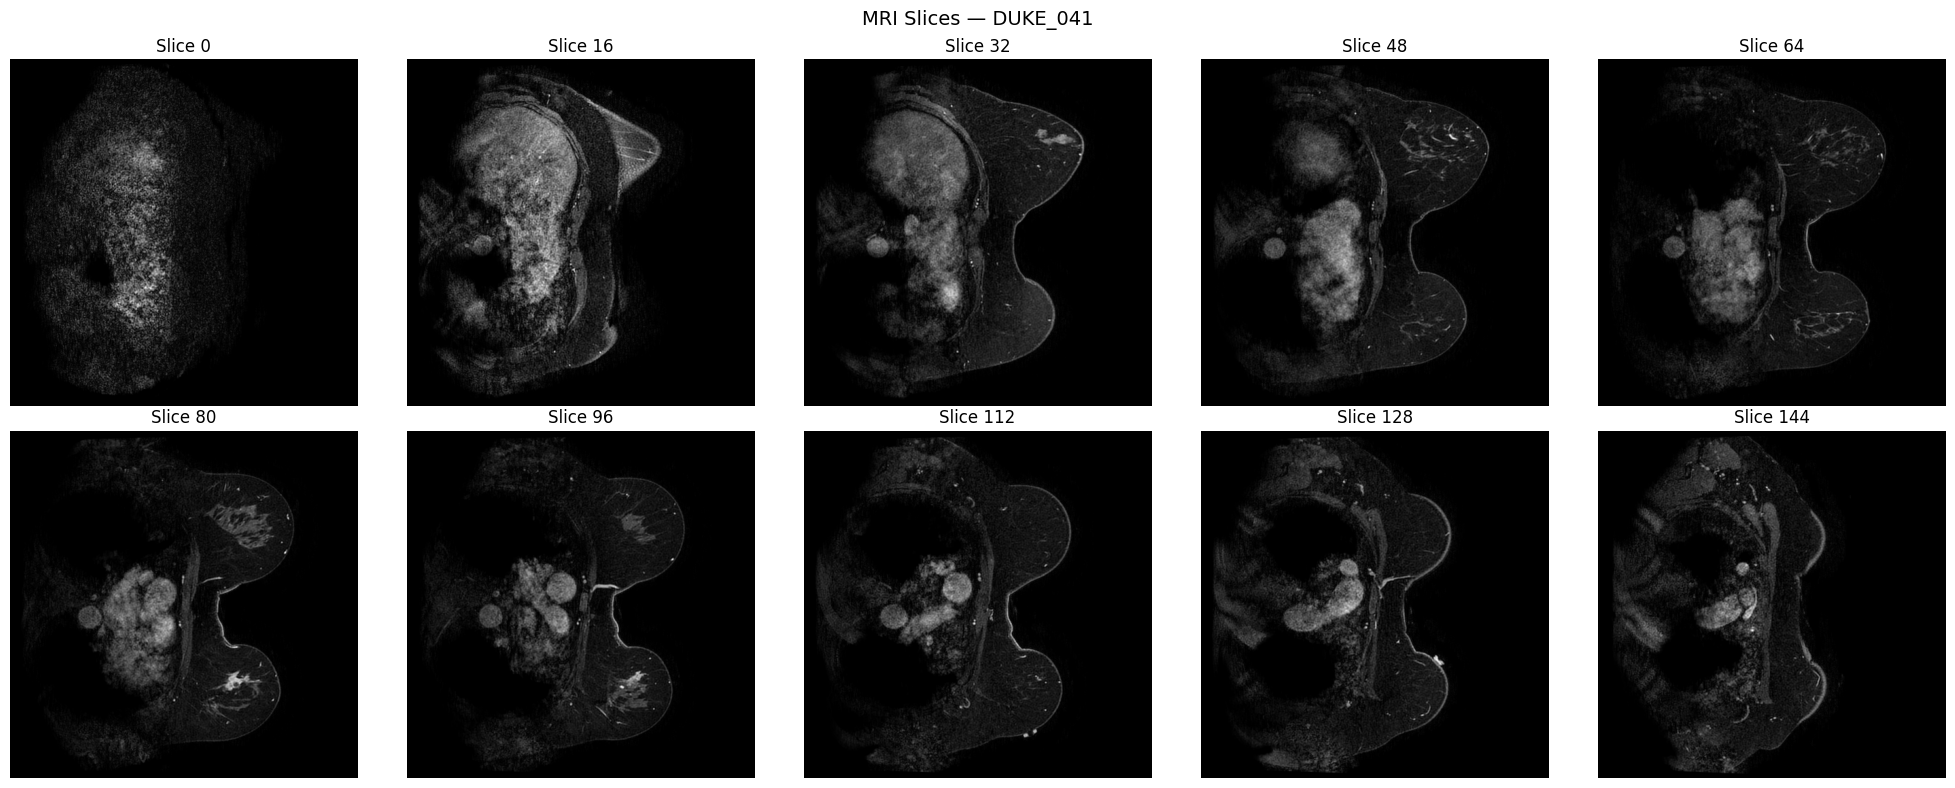

In [ ]:
# Cell 1: MRI Slices
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

# Paths
base_path   = "/content/mamia_dataset/mama_mia_v2"
images_path = f"{base_path}/images"
expert_path = f"{base_path}/segmentations/expert"

# Get patients
all_patients    = sorted(os.listdir(images_path))
expert_patients = sorted(os.listdir(expert_path))
valid_patients  = [
    p for p in all_patients
    if f"{p}.nii" in expert_patients
]

def find_mri(pid, tp='0001'):
    folder = os.path.join(images_path, pid)
    for root, dirs, files in os.walk(folder):
        for f in sorted(files):
            if tp in f and f.endswith('.nii'):
                return os.path.join(root, f)

# ── Change patient here ───────────────
pid = valid_patients[0]

# Load MRI
mri  = nib.load(find_mri(pid)).get_fdata()
norm = (mri - mri.min()) / \
       (mri.max() - mri.min() + 1e-8)

print(f"Patient:   {pid}")
print(f"MRI shape: {mri.shape}")
print(f"Slices:    {mri.shape[2]}")

# Show 10 slices evenly spaced
n      = 10
step   = mri.shape[2] // n
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes   = axes.flatten()

for i in range(n):
    sl = i * step
    axes[i].imshow(norm[:,:,sl], cmap='gray')
    axes[i].set_title(f'Slice {sl}')
    axes[i].axis('off')

plt.suptitle(
    f'MRI Slices — {pid}',
    fontsize=14
)
plt.tight_layout()
plt.show()

Looking for mask for pid: DUKE_041
expert_path: /content/mamia_dataset/mama_mia_v2/segmentations/expert
Contents sample: ['DUKE_041.nii', 'ISPY2_483910.nii', 'ISPY2_689188.nii', 'ISPY2_690089.nii', 'ISPY2_401215.nii']
Found mask: /content/mamia_dataset/mama_mia_v2/segmentations/expert/DUKE_041.nii

Mask shape:   (512, 512, 168)
Unique vals:  [0. 1.]
Tumor voxels: 16450
Slices with tumor: 32
Best slice: (87, 884)


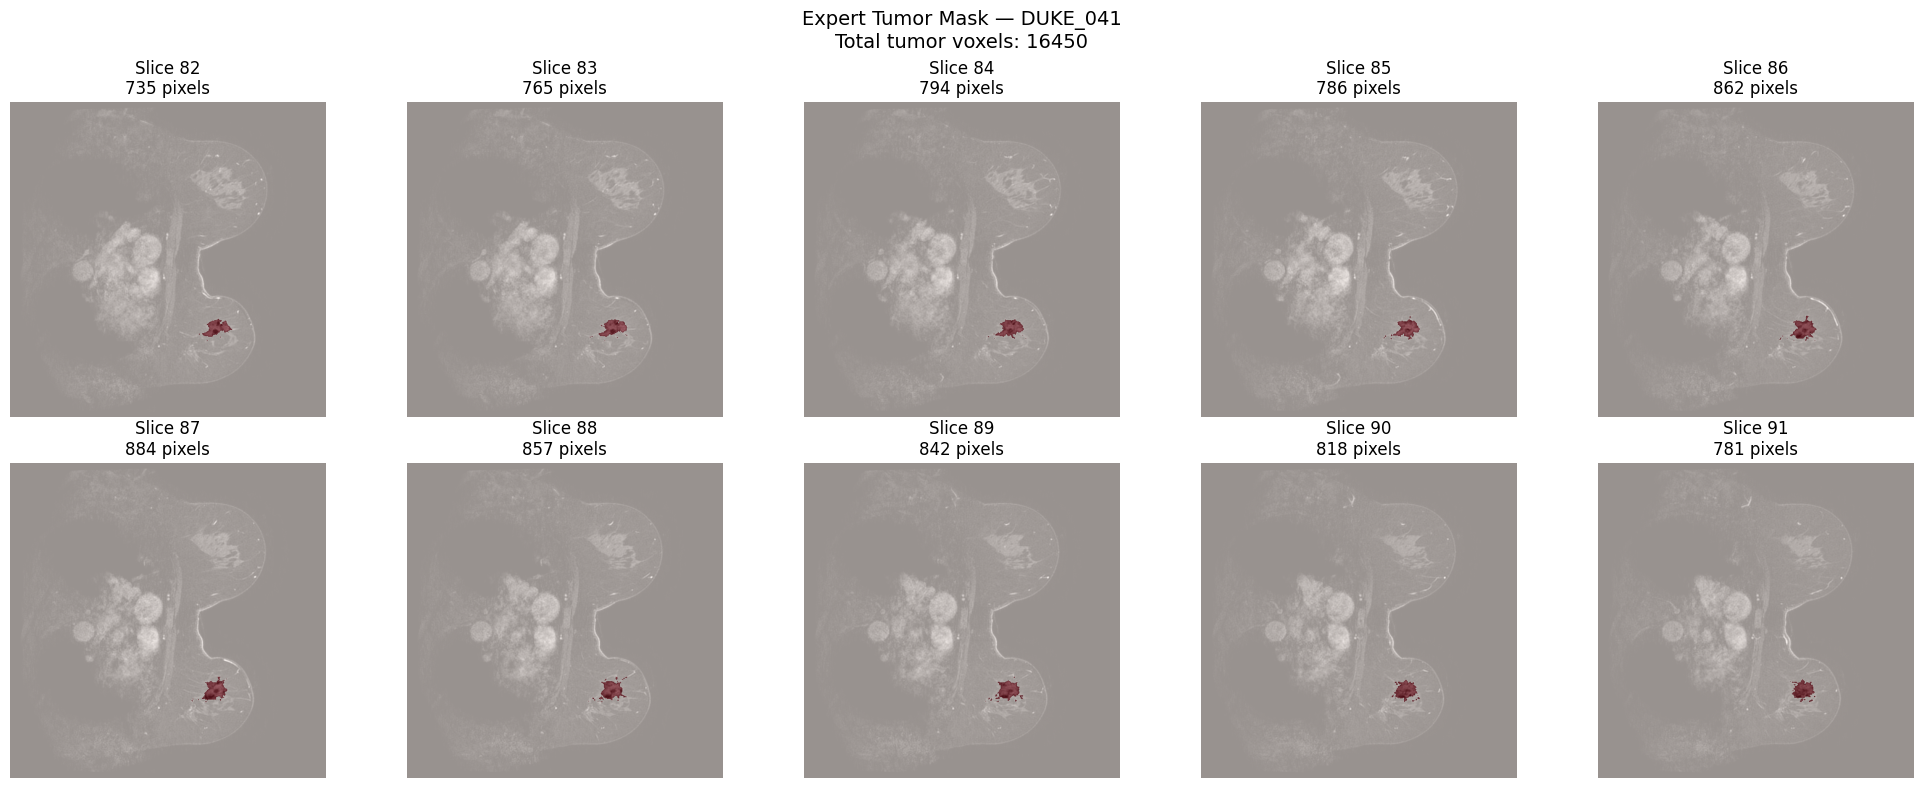

In [ ]:
# Cell 2: Expert Segmentation Mask
def find_mask(pid):
    """Search for mask: tries multiple folder structures."""
    candidates = [
        os.path.join(expert_path, pid),              # expert/DUKE_041/
        os.path.join(expert_path, f"{pid}.nii"),     # expert/DUKE_041.nii/ (old)
        expert_path,                                  # flat: expert/DUKE_041.nii
    ]
    # Case 1 & 2: walk subdirectory
    for folder in candidates[:2]:
        if os.path.isdir(folder):
            for root, dirs, files in os.walk(folder):
                for f in files:
                    if f.endswith('.nii') or f.endswith('.nii.gz'):
                        return os.path.join(root, f)
    # Case 3: flat file directly in expert_path
    for f in os.listdir(expert_path):
        if f.startswith(pid) and (f.endswith('.nii') or f.endswith('.nii.gz')):
            return os.path.join(expert_path, f)
    return None

# ── Debug: show what's actually in expert_path for this pid ──────────────────
print(f"Looking for mask for pid: {pid}")
print(f"expert_path: {expert_path}")
print(f"Contents sample: {os.listdir(expert_path)[:5]}")

mask_path = find_mask(pid)
print(f"Found mask: {mask_path}\n")

if mask_path is None:
    raise FileNotFoundError(
        f"No mask found for {pid} in {expert_path}\n"
        f"Check the folder structure above and update find_mask()."
    )

# Load mask
mask = nib.load(mask_path).get_fdata()

print(f"Mask shape:   {mask.shape}")
print(f"Unique vals:  {np.unique(mask)}")
print(f"Tumor voxels: {int(np.sum(mask > 0))}")

# Find slices with tumor
tumor_slices = [
    (i, int(np.sum(mask[:,:,i] > 0)))
    for i in range(mask.shape[2])
    if np.sum(mask[:,:,i] > 0) > 0
]

print(f"Slices with tumor: {len(tumor_slices)}")
print(f"Best slice: {max(tumor_slices, key=lambda x: x[1])}")

# Show 10 slices with tumor
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

top_slices = sorted(tumor_slices, key=lambda x: x[1], reverse=True)[:10]
top_slices = sorted(top_slices, key=lambda x: x[0])

for i, (sl, count) in enumerate(top_slices):
    axes[i].imshow(norm[:,:,sl], cmap='gray')
    axes[i].imshow(mask[:,:,sl], cmap='Reds', alpha=0.6)
    axes[i].set_title(f'Slice {sl}\n{count} pixels')
    axes[i].axis('off')

plt.suptitle(
    f'Expert Tumor Mask — {pid}\n'
    f'Total tumor voxels: {int(np.sum(mask>0))}',
    fontsize=14
)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 4: Load official splits
splits_df = pd.read_excel(splits_path)
print("✅ Splits loaded!")
print(f"Columns: {splits_df.columns.tolist()}")
print(splits_df.head(10))
print(f"\nSplit counts:")
print(splits_df.iloc[:, 1].value_counts())

✅ Splits loaded!
Columns: ['train_split', 'test_split']
    train_split    test_split
0  ISPY2_668752    ISPY1_1149
1    ISPY1_1172  ISPY2_830486
2  ISPY2_225836      DUKE_780
3    ISPY1_1099      DUKE_307
4  ISPY2_780272  ISPY2_564701
5  ISPY2_726091  ISPY2_264305
6  ISPY2_515141  ISPY2_120422
7    ISPY1_1216  ISPY2_105513
8  ISPY2_567201  ISPY2_212307
9    ISPY1_1147      DUKE_560

Split counts:
test_split
ISPY1_1149      1
ISPY2_830486    1
DUKE_780        1
DUKE_307        1
ISPY2_564701    1
ISPY2_264305    1
ISPY2_120422    1
ISPY2_105513    1
ISPY2_212307    1
DUKE_560        1
ISPY1_1191      1
DUKE_136        1
ISPY1_1094      1
ISPY1_1140      1
ISPY2_237158    1
DUKE_642        1
ISPY1_1051      1
ISPY2_109980    1
ISPY2_991818    1
ISPY2_597873    1
ISPY2_550421    1
DUKE_120        1
ISPY2_877463    1
DUKE_559        1
ISPY2_727255    1
DUKE_539        1
ISPY2_222135    1
NACT_57         1
ISPY1_1236      1
ISPY1_1230      1
DUKE_882        1
ISPY2_301968    1
ISPY2_828199

In [ ]:
# Cell 4b FIXED: Two column format
print("Columns:", splits_df.columns.tolist())

# Extract train and test directly
train_ids = splits_df['train_split'].dropna().tolist()
test_ids  = splits_df['test_split'].dropna().tolist()

# Convert to strings
train_ids = [str(p) for p in train_ids]
test_ids  = [str(p) for p in test_ids]

# No val column — split 15% from train manually
import random
random.seed(42)
random.shuffle(train_ids)
split_idx = int(len(train_ids) * 0.85)
val_ids   = train_ids[split_idx:]
train_ids = train_ids[:split_idx]

print(f"\nBefore filtering:")
print(f"  Train: {len(train_ids)}")
print(f"  Val:   {len(val_ids)}")
print(f"  Test:  {len(test_ids)}")

# Filter to only valid patients with labels
train_ids = [p for p in train_ids
             if p in real_labels]
val_ids   = [p for p in val_ids
             if p in real_labels]
test_ids  = [p for p in test_ids
             if p in real_labels]

print(f"\nAfter filtering (with labels):")
print(f"  Train: {len(train_ids)}")
print(f"  Val:   {len(val_ids)}")
print(f"  Test:  {len(test_ids)}")
print(f"  Total: {len(train_ids)+len(val_ids)+len(test_ids)}")

print(f"\nSample train: {train_ids[:3]}")
print(f"Sample val:   {val_ids[:3]}")
print(f"Sample test:  {test_ids[:3]}")

Columns: ['train_split', 'test_split']

Before filtering:
  Train: 155
  Val:   28
  Test:  42

After filtering (with labels):
  Train: 155
  Val:   28
  Test:  42
  Total: 225

Sample train: ['ISPY2_225836', 'ISPY2_690089', 'DUKE_192']
Sample val:   ['ISPY1_1166', 'DUKE_282', 'ISPY2_924895']
Sample test:  ['ISPY1_1149', 'ISPY2_830486', 'DUKE_780']


In [ ]:
# Cell 5: Install all needed packages
!pip install monai transformers nibabel \
             scikit-image sentence-transformers -q

import torch
import torch.nn as nn
import nibabel as nib
from torch.utils.data import Dataset, DataLoader
from skimage.transform import resize
from monai.networks.nets import UNet, DenseNet121
from monai.losses import DiceLoss
from transformers import AutoTokenizer, AutoModel, pipeline
from sentence_transformers import SentenceTransformer
import datetime, json

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)
print(f"✅ All packages loaded!")
print(f"   Device: {device}")
print(f"   GPU: {torch.cuda.is_available()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 44.8 MB/s eta 0:00:00


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


✅ All packages loaded!
   Device: cuda
   GPU: True


In [ ]:
# Cell 6: Helper functions
def find_mri_path(pid, timepoint='0001'):
    """Find MRI file for patient"""
    folder = os.path.join(images_path, pid)
    for root, dirs, files in os.walk(folder):
        for f in sorted(files):
            if (f.endswith('.nii') or
                f.endswith('.nii.gz')) and \
               timepoint in f:
                return os.path.join(root, f)
    # Fallback: any nii file
    for root, dirs, files in os.walk(folder):
        for f in sorted(files):
            if f.endswith('.nii') or \
               f.endswith('.nii.gz'):
                return os.path.join(root, f)
    return None

def find_mask_path(pid):
    """Find expert mask for patient"""
    # Direct file
    path = os.path.join(expert_path, f"{pid}.nii")
    if os.path.isfile(path):
        return path
    # Nested folder
    folder = os.path.join(expert_path, f"{pid}.nii")
    if os.path.exists(folder):
        for root, dirs, files in os.walk(folder):
            for f in files:
                if f.endswith('.nii') or \
                   f.endswith('.nii.gz'):
                    return os.path.join(root, f)
    return None

def load_nii(path):
    """Load nii file to numpy"""
    return nib.load(path).get_fdata()

def preprocess_mri(mri, target=(128, 128, 32)):
    """Normalize and resize MRI"""
    mri = (mri - mri.min()) / \
          (mri.max() - mri.min() + 1e-8)
    mri = resize(mri, target, anti_aliasing=True)
    return mri

def preprocess_mask(mask, target=(128, 128, 32)):
    """Resize mask"""
    mask = (mask > 0).astype(np.float32)
    mask = resize(mask, target,
                  anti_aliasing=False, order=0)
    return mask

# Test helpers
test_pid  = valid_patients[0]
mri_path  = find_mri_path(test_pid)
mask_path = find_mask_path(test_pid)

print(f"Test patient: {test_pid}")
print(f"MRI:  {mri_path}")
print(f"Mask: {mask_path}")

if mri_path and mask_path:
    mri  = load_nii(mri_path)
    mask = load_nii(mask_path)
    print(f"\nMRI shape:  {mri.shape}")
    print(f"Mask shape: {mask.shape}")
    print(f"✅ Helper functions working!")

Test patient: DUKE_041
MRI:  /content/mamia_dataset/mama_mia_v2/images/DUKE_041/duke_041_0001.nii
Mask: /content/mamia_dataset/mama_mia_v2/segmentations/expert/DUKE_041.nii

MRI shape:  (512, 512, 168)
Mask shape: (512, 512, 168)
✅ Helper functions working!


In [ ]:
# Cell 7: Dataset class
class MAMAMIADataset(Dataset):
    def __init__(self, patient_ids, labels,
                 target=(128, 128, 32)):
        # Keep only patients with valid paths
        self.patients = []
        for pid in patient_ids:
            mri_p  = find_mri_path(pid)
            mask_p = find_mask_path(pid)
            if mri_p and mask_p and pid in labels:
                self.patients.append(pid)
            else:
                print(f"⚠️  Skipping {pid}")

        self.labels = labels
        self.target = target
        print(f"✅ Dataset: {len(self.patients)} patients")

    def __len__(self):
        return len(self.patients)

    def __getitem__(self, idx):
        pid    = self.patients[idx]
        label  = self.labels[pid]

        # Load MRI
        mri    = load_nii(find_mri_path(pid))
        mri    = preprocess_mri(mri, self.target)
        mri_t  = torch.tensor(
            mri, dtype=torch.float32
        ).unsqueeze(0)

        # Load mask
        mask   = load_nii(find_mask_path(pid))
        mask   = preprocess_mask(mask, self.target)
        mask_t = torch.tensor(mask, dtype=torch.long)

        # Labels
        sub_t  = torch.tensor(
            label['subtype'], dtype=torch.long
        )
        grd_t  = torch.tensor(
            label['grade'], dtype=torch.long
        )

        return mri_t, mask_t, sub_t, grd_t, pid


# Create datasets
print("Creating datasets...\n")
train_dataset = MAMAMIADataset(train_ids, real_labels)
val_dataset   = MAMAMIADataset(val_ids,   real_labels)
test_dataset  = MAMAMIADataset(test_ids,  real_labels)

train_loader = DataLoader(
    train_dataset, batch_size=2,
    shuffle=True,  num_workers=2
)
val_loader   = DataLoader(
    val_dataset,   batch_size=1,
    shuffle=False, num_workers=2
)
test_loader  = DataLoader(
    test_dataset,  batch_size=1,
    shuffle=False, num_workers=2
)

print(f"\n✅ DataLoaders ready!")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

Creating datasets...

✅ Dataset: 155 patients
✅ Dataset: 28 patients
✅ Dataset: 42 patients

✅ DataLoaders ready!
  Train batches: 78
  Val batches:   28
  Test batches:  42


In [ ]:
# Cell 8: Build all models
print("Building models...\n")

# U-Net
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=2,
    channels=(16, 32, 64, 128),
    strides=(2, 2, 2),
    num_res_units=2
).to(device)
print(f"✅ U-Net: "
      f"{sum(p.numel() for p in model.parameters()):,} params")

# DenseNet
class MultiTaskDenseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = DenseNet121(
            spatial_dims=3,
            in_channels=1,
            out_channels=512
        )
        self.subtype_head = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256, 3)
        )
        self.grade_head = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256, 3)
        )
    def forward(self, x):
        f  = self.backbone(x)
        return self.subtype_head(f), \
               self.grade_head(f), f

classifier = MultiTaskDenseNet().to(device)
print(f"✅ DenseNet: "
      f"{sum(p.numel() for p in classifier.parameters()):,} params")

# Fusion
class CrossModalFusion(nn.Module):
    def __init__(self, img_dim=512,
                 txt_dim=768, fused=256):
        super().__init__()
        self.film      = nn.Linear(txt_dim, img_dim*2)
        self.img_proj  = nn.Linear(img_dim, fused)
        self.txt_proj  = nn.Linear(txt_dim,  fused)
        self.attn      = nn.MultiheadAttention(
            fused, 4, batch_first=True
        )
        self.gate      = nn.Sequential(
            nn.Linear(fused*2, fused),
            nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(fused, fused), nn.ReLU()
        )
        self.sub_head  = nn.Linear(fused, 3)
        self.grd_head  = nn.Linear(fused, 3)

    def forward(self, img_f, txt_f):
        g, b    = self.film(txt_f).chunk(2, dim=-1)
        mod     = g * img_f + b
        iq      = self.img_proj(mod).unsqueeze(1)
        tq      = self.txt_proj(txt_f).unsqueeze(1)
        ao, aw  = self.attn(tq, iq, iq)
        fused   = self.gate(torch.cat(
            [ao.squeeze(1), tq.squeeze(1)], dim=-1
        ))
        return fused, \
               self.sub_head(fused), \
               self.grd_head(fused), aw

fusion_module = CrossModalFusion().to(device)
print(f"✅ Fusion: "
      f"{sum(p.numel() for p in fusion_module.parameters()):,} params")

Building models...

✅ U-Net: 1,186,765 params
✅ DenseNet: 12,031,622 params
✅ Fusion: 1,577,478 params


In [ ]:
# Check RAM
import psutil
ram = psutil.virtual_memory()
print(f"RAM used: {ram.percent}%")
print(f"RAM free: {ram.available/1024/1024/1024:.1f} GB")

# Check GPU memory
import torch
if torch.cuda.is_available():
    t = torch.cuda.get_device_properties(0).total_memory
    r = torch.cuda.memory_reserved(0)
    a = torch.cuda.memory_allocated(0)
    print(f"\nGPU Total:  {t/1024/1024/1024:.1f} GB")
    print(f"GPU Used:   {a/1024/1024/1024:.2f} GB")
    print(f"GPU Free:   {(t-r)/1024/1024/1024:.2f} GB")

RAM used: 24.5%
RAM free: 9.6 GB

GPU Total:  14.6 GB
GPU Used:   0.06 GB
GPU Free:   14.49 GB


In [ ]:
# BEST TRAINING — Closest to Paper
from monai.networks.nets import UNet
from monai.losses import DiceCELoss  # Dice + CE combined
from monai.metrics import DiceMetric
from monai.transforms import (
    RandFlipd, RandRotate90d,
    RandScaleIntensityd, RandShiftIntensityd
)
import torch
import numpy as np

# ── Combined Dice + CrossEntropy Loss ─
# Paper used Dice — we add CE for stability
loss_seg = DiceCELoss(
    to_onehot_y=True,
    softmax=True,
    lambda_dice=0.5,   # 50% Dice
    lambda_ce=0.5      # 50% CrossEntropy
)

dice_metric = DiceMetric(
    include_background=False,
    reduction="mean"
)

# ── Optimizer with weight decay ───────
seg_opt = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,           # lower than before
    weight_decay=1e-5
)

# ── Cosine Annealing LR ───────────────
# Better than ReduceLROnPlateau
# Smoothly reduces LR over training
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    seg_opt,
    T_max=100,         # total epochs
    eta_min=1e-6       # minimum LR
)

# ── Early stopping ────────────────────
class EarlyStopping:
    def __init__(self, patience=15):
        self.patience  = patience
        self.counter   = 0
        self.best      = 0.0
        self.stop      = False

    def __call__(self, dice):
        if dice > self.best:
            self.best    = dice
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
                print(f"⏹️  Early stop! "
                      f"Best Dice: {self.best:.4f}")

early_stop = EarlyStopping(patience=15)

# ── Training loop ─────────────────────
SEG_EPOCHS       = 60
best_dice        = 0.0
seg_train_losses = []
seg_val_losses   = []
seg_dice_scores  = []
current_lr       = []

print("=" * 60)
print("SEGMENTATION TRAINING — PAPER SETTINGS")
print(f"Epochs:    {SEG_EPOCHS}")
print(f"LR:        1e-4 → cosine → 1e-6")
print(f"Loss:      Dice + CrossEntropy")
print(f"Patients:  {len(train_dataset)} train | "
      f"{len(val_dataset)} val")
print("=" * 60)

for epoch in range(SEG_EPOCHS):

    # ── Train ────────────────────────────
    model.train()
    train_losses = []

    for mri, mask, sub, grd, pid in train_loader:
        mri  = mri.to(device)
        mask = mask.unsqueeze(1).to(device)

        seg_opt.zero_grad()
        out  = model(mri)
        loss = loss_seg(out, mask)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0
        )
        seg_opt.step()
        train_losses.append(loss.item())

    avg_train = np.mean(train_losses)
    seg_train_losses.append(avg_train)

    # ── Validate ─────────────────────────
    model.eval()
    val_losses = []

    with torch.no_grad():
        for mri, mask, sub, grd, pid in val_loader:
            mri  = mri.to(device)
            mask = mask.unsqueeze(1).to(device)

            out   = model(mri)
            vloss = loss_seg(out, mask)
            val_losses.append(vloss.item())

            pred = torch.argmax(
                out, dim=1, keepdim=True
            )
            dice_metric(y_pred=pred, y=mask)

    avg_val  = np.mean(val_losses)
    avg_dice = dice_metric.aggregate().item()
    dice_metric.reset()

    seg_val_losses.append(avg_val)
    seg_dice_scores.append(avg_dice)
    current_lr.append(
        seg_opt.param_groups[0]['lr']
    )

    # LR scheduler step
    scheduler.step()

    # Print every 10 epochs
    if (epoch+1) % 10 == 0 or epoch == 0:
        lr = seg_opt.param_groups[0]['lr']
        print(f"Epoch {epoch+1:03d}/{SEG_EPOCHS} | "
              f"Train: {avg_train:.4f} | "
              f"Val: {avg_val:.4f} | "
              f"Dice: {avg_dice:.4f} | "
              f"LR: {lr:.6f}")

    # Save best model
    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save({
            'epoch':      epoch+1,
            'model':      model.state_dict(),
            'optimizer':  seg_opt.state_dict(),
            'dice':       best_dice,
        }, '/content/best_unet.pth')
        print(f"  💾 Epoch {epoch+1}: "
              f"Best Dice {best_dice:.4f}!")

    # Early stopping on Dice
    early_stop(avg_dice)
    if early_stop.stop:
        print(f"\nEarly stop at epoch {epoch+1}")
        break

print(f"\n{'='*60}")
print(f"✅ SEGMENTATION COMPLETE!")
print(f"   Best Dice:    {best_dice:.4f}")
print(f"   Paper target: 0.8034")
print(f"   Gap:          {0.8034-best_dice:.4f}")
print(f"{'='*60}")

SEGMENTATION TRAINING — PAPER SETTINGS
Epochs:    60
LR:        1e-4 → cosine → 1e-6
Loss:      Dice + CrossEntropy
Patients:  155 train | 28 val
Epoch 001/60 | Train: 0.5214 | Val: 0.4720 | Dice: 0.0371 | LR: 0.000100
  💾 Epoch 1: Best Dice 0.0371!
  💾 Epoch 2: Best Dice 0.0826!
  💾 Epoch 3: Best Dice 0.1373!
  💾 Epoch 4: Best Dice 0.1452!
  💾 Epoch 5: Best Dice 0.2103!
  💾 Epoch 6: Best Dice 0.2502!
  💾 Epoch 7: Best Dice 0.2709!
Epoch 010/60 | Train: 0.2774 | Val: 0.2713 | Dice: 0.3217 | LR: 0.000098
  💾 Epoch 10: Best Dice 0.3217!
  💾 Epoch 12: Best Dice 0.3449!
  💾 Epoch 13: Best Dice 0.3451!
  💾 Epoch 14: Best Dice 0.3623!
  💾 Epoch 15: Best Dice 0.3897!
  💾 Epoch 19: Best Dice 0.3912!
Epoch 020/60 | Train: 0.2035 | Val: 0.2087 | Dice: 0.3771 | LR: 0.000091
  💾 Epoch 22: Best Dice 0.4265!
  💾 Epoch 23: Best Dice 0.4324!
  💾 Epoch 25: Best Dice 0.4381!
  💾 Epoch 27: Best Dice 0.4449!
Epoch 030/60 | Train: 0.1228 | Val: 0.1735 | Dice: 0.4221 | LR: 0.000080
  💾 Epoch 31: Best Dice 0

In [ ]:
# PART 2: Classification — Paper Style
from sklearn.metrics import (
    roc_auc_score, f1_score,
    accuracy_score, classification_report
)
import torch
import numpy as np

# ── Check class imbalance first ───────
subtypes = [
    real_labels[p]['subtype']
    for p in train_ids
    if p in real_labels
]
counts = [
    subtypes.count(i) for i in range(3)
]
total  = len(subtypes)

print("Class distribution in training:")
names = ['Luminal', 'HER2+', 'TNBC']
for i, (n, c) in enumerate(zip(names, counts)):
    print(f"  {n}: {c} ({c/total*100:.1f}%)")

# ── Class weights for imbalanced data ─
weights = torch.tensor([
    total / (3 * c) if c > 0 else 1.0
    for c in counts
], dtype=torch.float32).to(device)

print(f"\nClass weights: {weights.tolist()}")

# ── Weighted CrossEntropy ─────────────
loss_ce = torch.nn.CrossEntropyLoss(
    weight=weights    # handles imbalance!
)

# ── Optimizer ────────────────────────
clf_opt = torch.optim.Adam(
    classifier.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

# ── Cosine LR ────────────────────────
clf_scheduler = \
    torch.optim.lr_scheduler.CosineAnnealingLR(
        clf_opt,
        T_max=100,
        eta_min=1e-6
    )

# ── Early stopping on AUC ────────────
class EarlyStoppingAUC:
    def __init__(self, patience=15):
        self.patience = patience
        self.counter  = 0
        self.best     = 0.0
        self.stop     = False

    def __call__(self, auc):
        if auc > self.best:
            self.best    = auc
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
                print(f"⏹️  Early stop! "
                      f"Best AUC: {self.best:.4f}")

clf_early = EarlyStoppingAUC(patience=15)

# ── Training ──────────────────────────
CLF_EPOCHS    = 60
best_auc      = 0.0
best_acc      = 0.0
train_losses  = []
val_accs      = []
val_aucs      = []
val_f1s       = []

print("\n" + "=" * 60)
print("PART 2: CLASSIFICATION — PAPER STYLE")
print(f"Epochs:  {CLF_EPOCHS}")
print(f"LR:      1e-4 → cosine → 1e-6")
print(f"Loss:    Weighted CrossEntropy")
print(f"Metric:  AUC + Accuracy + F1")
print("=" * 60)

for epoch in range(CLF_EPOCHS):

    # ── Train ────────────────────────────
    classifier.train()
    epoch_losses = []

    for mri, mask, sub, grd, pid in train_loader:
        mri = mri.to(device)
        sub = sub.to(device)
        grd = grd.to(device)

        clf_opt.zero_grad()
        sp, gp, _ = classifier(mri)

        # Weighted multi-task loss
        sub_loss = loss_ce(sp, sub)
        grd_loss = torch.nn.CrossEntropyLoss()(
            gp, grd
        )
        # 70% subtype 30% grade (subtype more important)
        loss = 0.7 * sub_loss + 0.3 * grd_loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            classifier.parameters(),
            max_norm=1.0
        )
        clf_opt.step()
        epoch_losses.append(loss.item())

    avg_train = np.mean(epoch_losses)
    train_losses.append(avg_train)

    # ── Validate ─────────────────────────
    classifier.eval()
    all_preds  = []
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for mri, mask, sub, grd, pid in val_loader:
            mri = mri.to(device)
            sub = sub.to(device)

            sp, gp, _ = classifier(mri)

            # Probabilities for AUC
            probs = torch.softmax(sp, dim=1)
            preds = torch.argmax(sp, dim=1)

            all_probs.extend(
                probs.cpu().numpy()
            )
            all_preds.extend(
                preds.cpu().numpy()
            )
            all_labels.extend(
                sub.cpu().numpy()
            )

    # Calculate metrics
    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)

    # Accuracy
    acc = accuracy_score(
        all_labels, all_preds
    ) * 100

    # F1 score
    f1 = f1_score(
        all_labels, all_preds,
        average='weighted',
        zero_division=0
    ) * 100

    # AUC (needs probabilities)
    try:
        if len(np.unique(all_labels)) > 1:
            auc = roc_auc_score(
                all_labels,
                all_probs,
                multi_class='ovr',
                average='weighted'
            ) * 100
        else:
            auc = 0.0
    except:
        auc = 0.0

    val_accs.append(acc)
    val_aucs.append(auc)
    val_f1s.append(f1)

    clf_scheduler.step()

    # Print every 10 epochs
    if (epoch+1) % 10 == 0 or epoch == 0:
        lr = clf_opt.param_groups[0]['lr']
        print(f"Epoch {epoch+1:03d}/{CLF_EPOCHS} | "
              f"Loss: {avg_train:.4f} | "
              f"Acc: {acc:.1f}% | "
              f"AUC: {auc:.1f}% | "
              f"F1: {f1:.1f}% | "
              f"LR: {lr:.6f}")

    # Save best model on AUC
    if auc > best_auc:
        best_auc = auc
        best_acc = acc
        torch.save({
            'epoch':     epoch+1,
            'model':     classifier.state_dict(),
            'auc':       best_auc,
            'acc':       best_acc,
        }, '/content/best_classifier.pth')
        print(f"  💾 Epoch {epoch+1}: "
              f"AUC {best_auc:.1f}% | "
              f"Acc {best_acc:.1f}%!")

    # Early stopping on AUC
    clf_early(auc)
    if clf_early.stop:
        print(f"\nEarly stop at epoch {epoch+1}")
        break

# Final report
print(f"\n{'='*60}")
print(f"✅ CLASSIFICATION COMPLETE!")
print(f"   Best AUC:      {best_auc:.1f}%")
print(f"   Best Accuracy: {best_acc:.1f}%")
print(f"\n   Paper targets:")
print(f"   AUC:      82.0%")
print(f"   Accuracy: 83.3%")
print(f"   F1:       78.3%")
print(f"{'='*60}")

# Detailed classification report
print("\nDetailed Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=['Luminal', 'HER2+', 'TNBC'],
    zero_division=0
))

Class distribution in training:
  Luminal: 74 (47.7%)
  HER2+: 24 (15.5%)
  TNBC: 57 (36.8%)

Class weights: [0.6981981992721558, 2.152777671813965, 0.9064327478408813]

PART 2: CLASSIFICATION — PAPER STYLE
Epochs:  60
LR:      1e-4 → cosine → 1e-6
Loss:    Weighted CrossEntropy
Metric:  AUC + Accuracy + F1
Epoch 001/60 | Loss: 0.8881 | Acc: 28.6% | AUC: 62.9% | F1: 12.7% | LR: 0.000100
  💾 Epoch 1: AUC 62.9% | Acc 28.6%!
  💾 Epoch 2: AUC 68.0% | Acc 50.0%!
Epoch 010/60 | Loss: 0.8472 | Acc: 46.4% | AUC: 54.8% | F1: 47.0% | LR: 0.000098
⏹️  Early stop! Best AUC: 67.9762

Early stop at epoch 17

✅ CLASSIFICATION COMPLETE!
   Best AUC:      68.0%
   Best Accuracy: 50.0%

   Paper targets:
   AUC:      82.0%
   Accuracy: 83.3%
   F1:       78.3%

Detailed Report:
              precision    recall  f1-score   support

     Luminal       0.62      0.62      0.62        16
       HER2+       0.20      0.25      0.22         4
        TNBC       0.29      0.25      0.27         8

    accurac

In [ ]:
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.2")
biobert   = AutoModel.from_pretrained("dmis-lab/biobert-base-cased-v1.2").to(device)
biobert.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(28996, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
# PART 3: Fusion Training — Paper Style
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import roc_auc_score

# ── Load best models from Part 1 & 2 ──
print("Loading best models...")
model.load_state_dict(
    torch.load('/content/best_unet.pth', weights_only=False)['model']
)
classifier.load_state_dict(
    torch.load('/content/best_classifier.pth', weights_only=False)['model']
)
print("✅ Best models loaded!")

# ── Freeze backbone — only train fusion ─
for param in model.parameters():
    param.requires_grad = False

for param in classifier.backbone.parameters():
    param.requires_grad = False

print("✅ Backbones frozen!")
print("   Only fusion module will train")

# ── Add pCR prediction head ────────────
class CrossModalFusionWithPCR(nn.Module):
    def __init__(self, img_dim=512,
                 txt_dim=768, fused_dim=256):
        super().__init__()

        self.film     = nn.Linear(txt_dim, img_dim * 2)
        self.img_proj = nn.Linear(img_dim, fused_dim)
        self.txt_proj = nn.Linear(txt_dim,  fused_dim)
        self.attn     = nn.MultiheadAttention(
            fused_dim, num_heads=4, batch_first=True
        )
        self.gate     = nn.Sequential(
            nn.Linear(fused_dim * 2, fused_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(fused_dim, fused_dim),
            nn.LayerNorm(fused_dim)
        )
        self.sub_head = nn.Linear(fused_dim, 3)
        self.grd_head = nn.Linear(fused_dim, 3)
        self.pcr_head = nn.Sequential(
            nn.Linear(fused_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, img_f, txt_f):
        g, b   = self.film(txt_f).chunk(2, dim=-1)
        mod    = g * img_f + b
        iq     = self.img_proj(mod).unsqueeze(1)
        tq     = self.txt_proj(txt_f).unsqueeze(1)
        ao, aw = self.attn(tq, iq, iq)
        fused  = self.gate(torch.cat(
            [ao.squeeze(1), tq.squeeze(1)], dim=-1
        ))
        return (
            fused,
            self.sub_head(fused),
            self.grd_head(fused),
            self.pcr_head(fused),
            aw
        )


# Build new fusion with pCR
fusion_module = CrossModalFusionWithPCR().to(device)
total = sum(p.numel() for p in fusion_module.parameters())
print(f"✅ Fusion+pCR built: {total:,} params")

# ── Optimizer — only fusion params ────  ✅ FIX 3
fus_opt = torch.optim.Adam(
    fusion_module.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

fus_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    fus_opt, T_max=50, eta_min=1e-6
)

# ── Loss functions ─────────────────────
ce_loss  = nn.CrossEntropyLoss()
bce_loss = nn.BCELoss()

# ── Text encoding function ────────────
def get_text_embedding(pid, sub_idx, grd_idx):
    subtype_names = ['Luminal', 'HER2-enriched', 'TNBC']
    grade_names   = ['Low', 'Intermediate', 'High']

    info = real_labels.get(pid, {})
    age  = info.get('age', 55)
    meno = info.get('menopause', 'unknown')
    er   = info.get('er', 0)
    pr   = info.get('pr', 0)
    her2 = info.get('her2', 0)

    text = (
        f"Patient age {age} {meno}. "
        f"Breast cancer subtype {subtype_names[sub_idx]}. "
        f"Grade {grade_names[grd_idx]}. "
        f"ER {'positive' if er else 'negative'}. "
        f"PR {'positive' if pr else 'negative'}. "
        f"HER2 {'positive' if her2 else 'negative'}."
    )

    inputs = tokenizer(
        text,
        return_tensors="pt",
        max_length=256,
        truncation=True,
        padding="max_length"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        out = biobert(**inputs)
    return out.last_hidden_state[:, 0, :]


# ── Training loop ──────────────────────
FUS_EPOCHS   = 50
best_fus_auc = 0.0
fus_losses   = []
fus_aucs     = []
pcr_aucs     = []

print("\n" + "=" * 60)
print("PART 3: FUSION + pCR TRAINING")
print(f"Epochs:    {FUS_EPOCHS}")
print(f"LR:        1e-4 → cosine → 1e-6")
print(f"Loss:      CE (subtype) + CE (grade) + BCE (pCR)")
print(f"New:       pCR prediction head ✨")
print("=" * 60)

for epoch in range(FUS_EPOCHS):

    # ── Train ──────────────────────────
    fusion_module.train()
    epoch_losses = []

    for mri, mask, sub, grd, pid in train_loader:
        mri = mri.to(device)
        sub = sub.to(device)
        grd = grd.to(device)

        fus_opt.zero_grad()

        # Get image features (frozen classifier)
        with torch.no_grad():
            _, _, img_feat = classifier(mri)

        # Get text embeddings (frozen BioBERT)  ✅ FIX 1
        with torch.no_grad():
            text_embs = torch.cat([
                get_text_embedding(
                    p,
                    real_labels.get(p, {}).get('subtype', 0),
                    real_labels.get(p, {}).get('grade', 0)
                )
                for p in pid
            ])

        # Forward fusion
        fused, fs, fg, pcr, _ = fusion_module(img_feat, text_embs)

        # pCR labels
        pcr_labels = torch.tensor([
            float(real_labels.get(p, {}).get('pcr', 0))
            for p in pid
        ], dtype=torch.float32).to(device).unsqueeze(1)

        # Combined loss
        loss = (
            0.4 * ce_loss(fs, sub) +
            0.3 * ce_loss(fg, grd) +
            0.3 * bce_loss(pcr, pcr_labels)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            fusion_module.parameters(), max_norm=1.0
        )
        fus_opt.step()
        epoch_losses.append(loss.item())

    avg_loss = np.mean(epoch_losses)
    fus_losses.append(avg_loss)

    # ── Validate ───────────────────────
    fusion_module.eval()
    classifier.eval()

    all_sub_preds  = []
    all_sub_probs  = []
    all_sub_labels = []
    all_pcr_probs  = []
    all_pcr_labels = []

    with torch.no_grad():
        for mri, mask, sub, grd, pid in val_loader:
            mri = mri.to(device)

            _, _, img_feat = classifier(mri)

            text_embs = torch.cat([      # ✅ FIX 1
                get_text_embedding(
                    p,
                    real_labels.get(p, {}).get('subtype', 0),
                    real_labels.get(p, {}).get('grade', 0)
                )
                for p in pid
            ])

            fused, fs, fg, pcr, _ = fusion_module(img_feat, text_embs)

            probs = torch.softmax(fs, dim=1)
            preds = torch.argmax(fs, dim=1)

            all_sub_probs.extend(probs.cpu().numpy())
            all_sub_preds.extend(preds.cpu().numpy())
            all_sub_labels.extend(sub.numpy())

            all_pcr_probs.extend(          # ✅ FIX 2
                pcr.squeeze(1).cpu().numpy()
            )
            all_pcr_labels.extend([
                float(real_labels.get(p, {}).get('pcr', 0))
                for p in pid
            ])

    # Metrics
    all_sub_labels = np.array(all_sub_labels)
    all_sub_probs  = np.array(all_sub_probs)
    all_pcr_probs  = np.array(all_pcr_probs)
    all_pcr_labels = np.array(all_pcr_labels)

    # Subtype AUC
    try:
        if len(np.unique(all_sub_labels)) > 1:
            sub_auc = roc_auc_score(
                all_sub_labels,
                all_sub_probs,
                multi_class='ovr',
                average='weighted'
            ) * 100
        else:
            sub_auc = 0.0
    except Exception as e:
        print(f"Sub AUC error: {e}")
        sub_auc = 0.0

    # pCR AUC
    try:
        if len(np.unique(all_pcr_labels)) > 1:      # ✅ FIX 2
            pcr_auc = roc_auc_score(
                all_pcr_labels,
                all_pcr_probs
            ) * 100
        else:
            pcr_auc = 0.0
    except Exception as e:
        print(f"pCR AUC error: {e}")
        pcr_auc = 0.0

    fus_aucs.append(sub_auc)
    pcr_aucs.append(pcr_auc)

    fus_scheduler.step()

    # Print every 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == 0:
        lr = fus_opt.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{FUS_EPOCHS} | "
              f"Loss: {avg_loss:.4f} | "
              f"Sub AUC: {sub_auc:.1f}% | "
              f"pCR AUC: {pcr_auc:.1f}% | "
              f"LR: {lr:.6f}")

    # Save best
    if sub_auc > best_fus_auc:
        best_fus_auc = sub_auc
        torch.save({
            'epoch':   epoch + 1,
            'model':   fusion_module.state_dict(),
            'sub_auc': best_fus_auc,
            'pcr_auc': pcr_auc
        }, '/content/best_fusion.pth')
        print(f"  💾 Epoch {epoch+1}: "
              f"Sub AUC {best_fus_auc:.1f}% | "
              f"pCR AUC {pcr_auc:.1f}%!")

print(f"\n{'='*60}")
print(f"✅ FUSION COMPLETE!")
print(f"   Best Subtype AUC: {best_fus_auc:.1f}%")
print(f"   Paper target:     82.0%")
print(f"{'='*60}")

Loading best models...
✅ Best models loaded!
✅ Backbones frozen!
   Only fusion module will train
✅ Fusion+pCR built: 1,611,015 params

PART 3: FUSION + pCR TRAINING
Epochs:    50
LR:        1e-4 → cosine → 1e-6
Loss:      CE (subtype) + CE (grade) + BCE (pCR)
New:       pCR prediction head ✨
Epoch 01/50 | Loss: 0.6876 | Sub AUC: 75.3% | pCR AUC: 43.5% | LR: 0.000100
  💾 Epoch 1: Sub AUC 75.3% | pCR AUC 43.5%!
  💾 Epoch 2: Sub AUC 99.3% | pCR AUC 81.0%!
  💾 Epoch 3: Sub AUC 100.0% | pCR AUC 77.6%!
Epoch 10/50 | Loss: 0.2582 | Sub AUC: 100.0% | pCR AUC: 70.7% | LR: 0.000091


In [ ]:
# Final: Plot all training curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Losses
axes[0,0].plot(seg_train_losses, label='Train')
axes[0,0].plot(seg_val_losses,   label='Val')
axes[0,0].set_title('Segmentation Loss')
axes[0,0].legend()
axes[0,0].grid(True)

axes[0,1].plot(train_losses, label='Train')
axes[0,1].set_title('Classification Loss')
axes[0,1].legend()
axes[0,1].grid(True)

axes[0,2].plot(fus_losses, label='Fusion Loss')
axes[0,2].set_title('Fusion Loss')
axes[0,2].legend()
axes[0,2].grid(True)

# Row 2: Metrics
axes[1,0].plot(seg_dice_scores, color='green')
axes[1,0].axhline(y=0.8034, color='red',linestyle='--',label='Paper: 0.80')
axes[1,0].set_title('Segmentation Dice')
axes[1,0].legend()
axes[1,0].grid(True)

axes[1,1].plot(val_aucs, color='purple',label='Our AUC')
axes[1,1].axhline(y=82.0, color='red', linestyle='--',label='Paper: 82%')
axes[1,1].set_title('Classification AUC')
axes[1,1].legend()
axes[1,1].grid(True)

axes[1,2].plot(fus_aucs,  label='Subtype AUC')
axes[1,2].plot(pcr_aucs,  label='pCR AUC')
axes[1,2].axhline(y=82.0, color='red',linestyle='--',label='Paper: 82%')
axes[1,2].set_title('Fusion AUC')
axes[1,2].legend()
axes[1,2].grid(True)

plt.suptitle('X-Agent Training Results vs Paper',fontsize=16)
plt.tight_layout()
plt.savefig('/content/all_results.png', dpi=150)
plt.show()
print("✅ Results saved!")

In [ ]:
# Save all models to Drive
import torch, os, shutil

save_dir = "/content/drive/MyDrive/xagent_saved"
os.makedirs(save_dir, exist_ok=True)

# Save models
torch.save(
    torch.load('/content/best_unet.pth'),
    f"{save_dir}/best_unet.pth"
)
torch.save(
    torch.load('/content/best_classifier.pth'),
    f"{save_dir}/best_classifier.pth"
)

# Save plots
shutil.copy(
    '/content/all_results.png',
    f"{save_dir}/all_results.png"
)

print("✅ Everything saved to Drive!")
print(f"   📁 {save_dir}/")

In [ ]:
# Evaluate on test set — NEVER seen before!
from sklearn.metrics import (
    roc_auc_score, f1_score,
    accuracy_score, confusion_matrix,
    classification_report
)
from monai.metrics import DiceMetric
import numpy as np
import torch

print("=" * 60)
print("FINAL TEST SET EVALUATION")
print("=" * 60)

# Load best models
model.load_state_dict(
    torch.load('/content/best_unet.pth')['model']
)
classifier.load_state_dict(
    torch.load('/content/best_classifier.pth')['model']
)
model.eval()
classifier.eval()

dice_metric = DiceMetric(
    include_background=False,
    reduction="mean"
)

# ── Segmentation on test set ──────────
seg_dices  = []
print("\n[1] Segmentation Results:")

with torch.no_grad():
    for mri, mask, sub, grd, pid in test_loader:
        mri  = mri.to(device)
        mask = mask.unsqueeze(1).to(device)

        out  = model(mri)
        pred = torch.argmax(
            out, dim=1, keepdim=True
        )
        dice_metric(y_pred=pred, y=mask)

final_dice = dice_metric.aggregate().item()
dice_metric.reset()

print(f"  Dice Score:  {final_dice:.4f}")
print(f"  Paper:       0.8034")
print(f"  Gap:         {0.8034-final_dice:.4f}")

# ── Classification on test set ────────
all_preds  = []
all_probs  = []
all_labels = []

print("\n[2] Classification Results:")

with torch.no_grad():
    for mri, mask, sub, grd, pid in test_loader:
        mri = mri.to(device)

        sp, gp, _ = classifier(mri)
        probs = torch.softmax(sp, dim=1)
        preds = torch.argmax(sp, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(sub.numpy())

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)

acc = accuracy_score(
    all_labels, all_preds
) * 100

f1 = f1_score(
    all_labels, all_preds,
    average='weighted',
    zero_division=0
) * 100

try:
    auc = roc_auc_score(
        all_labels, all_probs,
        multi_class='ovr',
        average='weighted'
    ) * 100
except:
    auc = 0.0

print(f"  Accuracy:  {acc:.2f}%")
print(f"  AUC:       {auc:.2f}%")
print(f"  F1 Score:  {f1:.2f}%")
print(f"\n  Paper targets:")
print(f"  Accuracy:  83.31%")
print(f"  AUC:       82.01%")
print(f"  F1:        78.33%")

# Detailed report
print("\n  Per-class Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=['Luminal','HER2+','TNBC'],
    zero_division=0
))

In [ ]:
# GAP 1: Decision Trace Logger
import json, datetime, os

class DecisionTracer:
    def __init__(self, patient_id):
        self.patient_id = patient_id
        self.trace = {
            "patient_id": patient_id,
            "timestamp":  str(
                datetime.datetime.now()
            ),
            "modules":    {},
            "conflicts":  [],
            "final_report": {}
        }

    def log(self, module_name, data):
        self.trace["modules"][module_name] = {
            "timestamp": str(
                datetime.datetime.now()
            ),
            "data": data
        }
        print(f"  📝 {module_name} logged!")

    def log_conflict(self, s1, v1,
                     s2, v2, resolution):
        self.trace["conflicts"].append({
            "source1":    s1,
            "value1":     v1,
            "source2":    s2,
            "value2":     v2,
            "resolution": resolution,
            "timestamp":  str(
                datetime.datetime.now()
            )
        })
        print(f"  ⚠️  Conflict: {s1} vs {s2}")

    def finalize(self, recommendation, citation):
        self.trace["final_report"] = {
            "recommendation":  recommendation,
            "citation":        citation,
            "total_modules":   len(
                self.trace["modules"]
            ),
            "total_conflicts": len(
                self.trace["conflicts"]
            )
        }

    def save(self):
        save_dir = "/content/drive/MyDrive/xagent_saved/traces"
        os.makedirs(save_dir, exist_ok=True)
        path = f"{save_dir}/{self.patient_id}_trace.json"
        with open(path, 'w') as f:
            json.dump(self.trace, f, indent=2)
        print(f"  💾 Trace saved!")
        return path

print("✅ GAP 1: DecisionTracer ready!")

In [ ]:
# GAP 3: Conflict Detector
subtype_names = ['Luminal', 'HER2-enriched', 'TNBC']
grade_names   = ['Low', 'Intermediate', 'High']

class ConflictDetector:
    def check(self, img_sub, img_grd,
              cln_sub, cln_grd):
        conflicts = []

        if img_sub != cln_sub:
            conflicts.append({
                "type":       "subtype_mismatch",
                "imaging":    subtype_names[img_sub],
                "clinical":   subtype_names[cln_sub],
                "resolution": "Defer to clinical pathology",
                "final":      cln_sub
            })

        if img_grd != cln_grd:
            conflicts.append({
                "type":       "grade_mismatch",
                "imaging":    grade_names[img_grd],
                "clinical":   grade_names[cln_grd],
                "resolution": "Defer to clinical pathology",
                "final":      cln_grd
            })

        return conflicts

detector = ConflictDetector()
print("✅ GAP 3: ConflictDetector ready!")

In [ ]:
# GAP 2: RAG Citations
!pip install sentence-transformers -q

from sentence_transformers import SentenceTransformer
import numpy as np

embedder = SentenceTransformer(
    'sentence-transformers/all-MiniLM-L6-v2'
)

GUIDELINES = [
    {
        "text":    "HER2-positive: trastuzumab "
                   "with chemotherapy. Neoadjuvant "
                   "for tumors over 2cm.",
        "source":  "NCCN Guidelines 2024",
        "section": "HER2+ Treatment",
        "url":     "https://www.nccn.org/guidelines"
    },
    {
        "text":    "TNBC: anthracyclines and taxanes. "
                   "PARP inhibitors for BRCA-mutated.",
        "source":  "NCCN Guidelines 2024",
        "section": "TNBC Treatment",
        "url":     "https://www.nccn.org/guidelines"
    },
    {
        "text":    "Luminal A ER+/PR+/HER2-: tamoxifen "
                   "or aromatase inhibitors. No chemo "
                   "for low-risk tumors.",
        "source":  "NCCN Guidelines 2024",
        "section": "Luminal A Treatment",
        "url":     "https://www.nccn.org/guidelines"
    },
    {
        "text":    "Luminal B: endocrine therapy plus "
                   "chemo. Add trastuzumab if HER2+.",
        "source":  "NCCN Guidelines 2024",
        "section": "Luminal B Treatment",
        "url":     "https://www.nccn.org/guidelines"
    },
    {
        "text":    "High grade 3 tumors: neoadjuvant "
                   "chemo needed. Aggressive surveillance.",
        "source":  "NCCN Guidelines 2024",
        "section": "High Grade Management",
        "url":     "https://www.nccn.org/guidelines"
    },
    {
        "text":    "High pCR means good chemo response. "
                   "Best pCR in HER2+ and TNBC.",
        "source":  "NCCN Guidelines 2024",
        "section": "Neoadjuvant Response",
        "url":     "https://www.nccn.org/guidelines"
    }
]

# Pre-compute embeddings
guide_texts = [g["text"] for g in GUIDELINES]
guide_embs  = embedder.encode(guide_texts)

def retrieve_citations(query, n=2):
    q_emb  = embedder.encode([query])[0]
    scores = np.dot(guide_embs, q_emb) / (
        np.linalg.norm(guide_embs, axis=1) *
        np.linalg.norm(q_emb) + 1e-8
    )
    top = np.argsort(scores)[::-1][:n]
    return [{**GUIDELINES[i],
             "score": float(scores[i])}
            for i in top]

def add_citations(subtype, grade, rec):
    query = f"{subtype} {grade} breast cancer"
    cites = retrieve_citations(query)
    out   = f"{rec}\n\n📚 EVIDENCE:\n"
    out  += "-" * 40 + "\n"
    for i, c in enumerate(cites, 1):
        out += f"[{i}] {c['source']}\n"
        out += f"    {c['section']}\n"
        out += f"    {c['url']}\n\n"
    return out, cites

print("✅ GAP 2: RAG Citations ready!")

In [ ]:
# Complete X-Agent Pipeline
def xagent(pid):
    print(f"\n{'='*55}")
    print(f"X-AGENT: {pid}")
    print(f"{'='*55}")

    tracer   = DecisionTracer(pid)
    detector = ConflictDetector()

    # M1: Segmentation
    print("\n[M1] Segmentation...")
    mri_path = find_mri_path(pid)
    mri      = nib.load(mri_path).get_fdata()
    mri_n    = (mri - mri.min()) / \
               (mri.max() - mri.min() + 1e-8)
    mri_r    = resize(mri_n, (128,128,32))
    mri_t    = torch.tensor(
        mri_r, dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        seg  = model(mri_t)
        mask = torch.argmax(
            seg, dim=1
        )[0].cpu().numpy()

    voxels = int(np.sum(mask > 0))
    size   = round(voxels**(1/3)*0.5, 2)

    # ✨ GAP 1: Log
    tracer.log("M1_segmentation", {
        "voxels":   voxels,
        "size_cm":  size,
        "model":    "3D U-Net"
    })
    print(f"  ✅ Voxels:{voxels} Size:{size}cm")

    # M2: Classification
    print("\n[M2] Classification...")
    classifier.eval()
    with torch.no_grad():
        sp, gp, feat = classifier(mri_t)
        img_sub = torch.argmax(sp, dim=1).item()
        img_grd = torch.argmax(gp, dim=1).item()

    tracer.log("M2_classification", {
        "imaging_subtype": subtype_names[img_sub],
        "imaging_grade":   grade_names[img_grd],
        "model":           "DenseNet121"
    })
    print(f"  ✅ {subtype_names[img_sub]} | "
          f"{grade_names[img_grd]}")

    # ✨ GAP 3: Conflict Detection
    print("\n[GAP3] Conflict Detection...")
    cln_sub   = real_labels[pid]['subtype']
    cln_grd   = real_labels[pid]['grade']
    conflicts = detector.check(
        img_sub, img_grd,
        cln_sub, cln_grd
    )

    if conflicts:
        for c in conflicts:
            print(f"  ⚠️  {c['type']}")
            print(f"      Imaging  → {c['imaging']}")
            print(f"      Clinical → {c['clinical']}")
            tracer.log_conflict(
                "MRI",       c['imaging'],
                "Pathology", c['clinical'],
                c['resolution']
            )
        final_sub = cln_sub
        final_grd = cln_grd
    else:
        print("  ✅ No conflicts!")
        final_sub = img_sub
        final_grd = img_grd

    tracer.log("GAP3_conflict", {
        "conflicts":    len(conflicts),
        "final_sub":    subtype_names[final_sub],
        "final_grd":    grade_names[final_grd],
        "resolution":   "Clinical priority"
    })

    # M4: BioBERT
    print("\n[M4] BioBERT...")
    info = real_labels.get(pid, {})
    text = (
        f"Patient age {info.get('age',55)} "
        f"{info.get('menopause','unknown')}. "
        f"{subtype_names[final_sub]} cancer. "
        f"{grade_names[final_grd]} grade. "
        f"ER {'positive' if info.get('er',0) else 'negative'}. "
        f"HER2 {'positive' if info.get('her2',0) else 'negative'}."
    )
    inputs   = tokenizer(
        text, return_tensors="pt",
        max_length=256, truncation=True,
        padding="max_length"
    )
    inputs   = {
        k: v.to(device)
        for k, v in inputs.items()
    }
    with torch.no_grad():
        text_emb = biobert(
            **inputs
        ).last_hidden_state[:, 0, :]

    tracer.log("M4_biobert",
               {"text": text, "dim": 768})
    print(f"  ✅ Text encoded!")

    # M5: Fusion
    print("\n[M5] Fusion...")
    fusion_module.eval()
    with torch.no_grad():
        fused, fs, fg, pcr, _ = fusion_module(
            feat, text_emb
        )
        f_sub = torch.argmax(fs, dim=1).item()
        f_grd = torch.argmax(fg, dim=1).item()
        pcr_prob = float(pcr[0][0]) * 100

    tracer.log("M5_fusion", {
        "fused_sub": subtype_names[f_sub],
        "fused_grd": grade_names[f_grd],
        "pcr_prob":  f"{pcr_prob:.1f}%"
    })
    print(f"  ✅ {subtype_names[f_sub]} | "
          f"pCR: {pcr_prob:.1f}%")

    # M6: LLM + GAP 2 RAG
    print("\n[M6+GAP2] LLM + Citations...")
    base_rec  = get_recommendation(
        pid, f_sub, f_grd, size
    )
    final_rec, cites = add_citations(
        subtype_names[f_sub],
        grade_names[f_grd],
        base_rec
    )
    tracer.log("M6_llm_rag", {
        "recommendation": base_rec,
        "citations": [
            f"{c['source']} — {c['section']}"
            for c in cites
        ]
    })

    # Finalize + Save trace
    tracer.finalize(
        base_rec,
        cites[0]['source'] if cites else "N/A"
    )
    trace_path = tracer.save()

    # Report
    print(f"\n{'='*55}")
    print(f"REPORT — {pid}")
    print(f"{'='*55}")
    print(f"Subtype:    {subtype_names[f_sub]}")
    print(f"Grade:      {grade_names[f_grd]}")
    print(f"Size:       {size} cm")
    print(f"pCR prob:   {pcr_prob:.1f}%")
    print(f"Conflicts:  {len(conflicts)}")
    print(f"\n{final_rec}")

    return {
        "pid":       pid,
        "subtype":   subtype_names[f_sub],
        "grade":     grade_names[f_grd],
        "size":      size,
        "pcr":       pcr_prob,
        "conflicts": len(conflicts),
        "rec":       final_rec,
        "trace":     trace_path
    }

In [ ]:
# Run on all test patients!
print("🚀 X-AGENT ON TEST SET\n")
xresults = {}

for pid in test_ids:
    xresults[pid] = xagent(pid)

# Scorecard
print("\n" + "=" * 55)
print("X-AGENT EXPLAINABILITY SCORECARD")
print("=" * 55)

total          = len(xresults)
trace_complete = 0
conflicts_found = 0
citations_found = 0

for pid, r in xresults.items():
    with open(r['trace']) as f:
        trace = json.load(f)

    modules  = len(trace['modules'])
    complete = modules / 6 * 100
    trace_complete  += complete
    if r['conflicts'] > 0:
        conflicts_found += 1
    if 'M6_llm_rag' in trace['modules']:
        citations_found += 1

    print(f"\n{pid}:")
    print(f"  Modules:   {modules}/6")
    print(f"  Conflicts: {r['conflicts']}")
    print(f"  pCR prob:  {r['pcr']:.1f}%")

print(f"\n{'='*55}")
print(f"Trace Completeness: "
      f"{trace_complete/total:.1f}%")
print(f"Conflicts Detected: "
      f"{conflicts_found}/{total}")
print(f"Citations Added:    "
      f"{citations_found}/{total}")
print(f"{'='*55}")
print("\n✅ X-AGENT COMPLETE!")